In [3]:
import zipfile, shutil, os

# Try archive.zip instead
with zipfile.ZipFile("/content/archive.zip", "r") as z:
    z.extractall("/content/raw")

# See what was extracted
for root, dirs, files in os.walk("/content/raw"):
    if dirs:
        print(root, "-->", dirs)

/content/raw --> ['dataset2-master', 'dataset-master']
/content/raw/dataset2-master --> ['dataset2-master']
/content/raw/dataset2-master/dataset2-master --> ['images']
/content/raw/dataset2-master/dataset2-master/images --> ['TEST_SIMPLE', 'TRAIN', 'TEST']
/content/raw/dataset2-master/dataset2-master/images/TEST_SIMPLE --> ['EOSINOPHIL', 'MONOCYTE', 'NEUTROPHIL', 'LYMPHOCYTE']
/content/raw/dataset2-master/dataset2-master/images/TRAIN --> ['EOSINOPHIL', 'MONOCYTE', 'NEUTROPHIL', 'LYMPHOCYTE']
/content/raw/dataset2-master/dataset2-master/images/TEST --> ['EOSINOPHIL', 'MONOCYTE', 'NEUTROPHIL', 'LYMPHOCYTE']
/content/raw/dataset-master --> ['dataset-master']
/content/raw/dataset-master/dataset-master --> ['Annotations', 'JPEGImages']


In [4]:
import shutil, os

shutil.copytree(
    "/content/raw/dataset2-master/dataset2-master/images/TRAIN",
    "/content/data"
)

print(os.listdir("/content/data"))

['EOSINOPHIL', 'MONOCYTE', 'NEUTROPHIL', 'LYMPHOCYTE']


In [6]:
!pip install -q torch torchvision tqdm scikit-learn seaborn matplotlib


[INFO] Using device: cuda
[INFO] Classes found: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
[INFO] Total samples: 9957
[INFO] Train: 6969 | Val: 1493 | Test: 1495
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 136MB/s] 


[INFO] InceptionV3 loaded. Final FC layers replaced for 4 classes.

Epoch 1/10


  Train Loss: 1.9002 | Train Acc: 0.3254
  Val   Loss: 1.3082 | Val   Acc: 0.4615
  [✓] Best model saved (val_acc=0.4615)

Epoch 2/10


  Train Loss: 1.7487 | Train Acc: 0.4319
  Val   Loss: 1.2477 | Val   Acc: 0.5144
  [✓] Best model saved (val_acc=0.5144)

Epoch 3/10


...

  Train Loss: 1.5333 | Train Acc: 0.5404
  Val   Loss: 1.1327 | Val   Acc: 0.5908
  [✓] Best model saved (val_acc=0.5908)

Epoch 7/10


  Train Loss: 1.5134 | Train Acc: 0.5471
  Val   Loss: 1.1322 | Val   Acc: 0.5834
  [!] No improvement. Patience: 1/3

Epoch 8/10


  Train Loss: 1.4998 | Train Acc: 0.5519
  Val   Loss: 1.1207 | Val   Acc: 0.6015
  [✓] Best model saved (val_acc=0.6015)

Epoch 9/10


  Train Loss: 1.4900 | Train Acc: 0.5576
  Val   Loss: 1.1140 | Val   Acc: 0.5961
  [!] No improvement. Patience: 1/3

Epoch 10/10


  Train Loss: 1.4724 | Train Acc: 0.5656
  Val   Loss: 1.1085 | Val   Acc: 0.5961
  [!] No improvement. Patience: 2/3

[INFO] Training complete. Best Val Acc: 0.6015


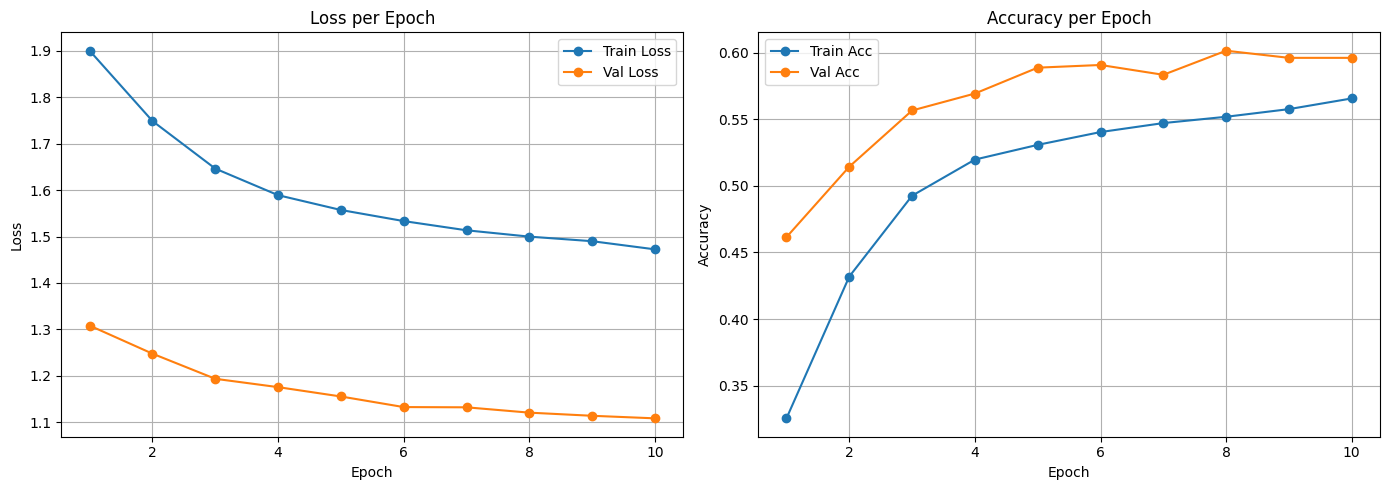

[INFO] Training plot saved → train_val_plot.png


  Test : 100%|██████████| 47/47 [00:14<00:00,  3.29it/s]



TEST SET METRICS

Accuracy: 0.6107

Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.61      0.40      0.48       380
  LYMPHOCYTE       0.59      0.75      0.66       356
    MONOCYTE       0.76      0.65      0.70       387
  NEUTROPHIL       0.53      0.66      0.58       372

    accuracy                           0.61      1495
   macro avg       0.62      0.61      0.61      1495
weighted avg       0.62      0.61      0.61      1495

ROC-AUC per class:
  EOSINOPHIL          : 0.8125
  LYMPHOCYTE          : 0.8730
  MONOCYTE            : 0.8950
  NEUTROPHIL          : 0.7932
Macro ROC-AUC: 0.8434


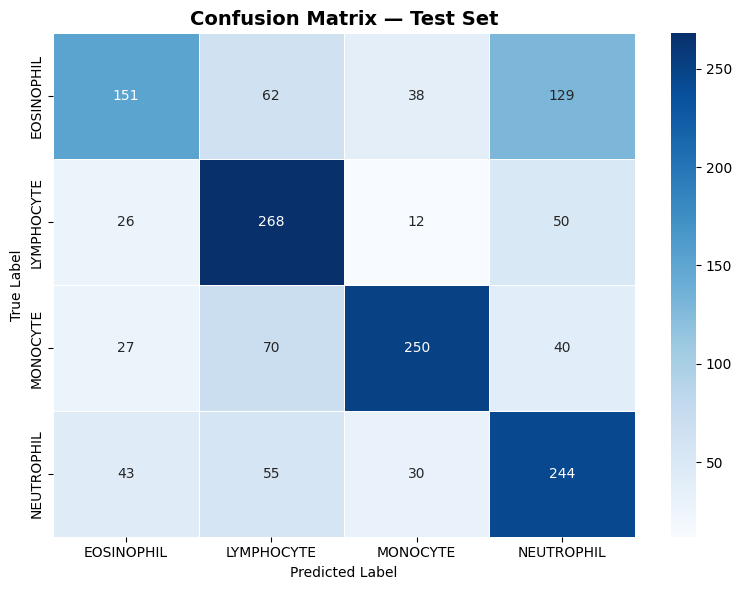

[INFO] Confusion matrix saved → confusion_matrix.png


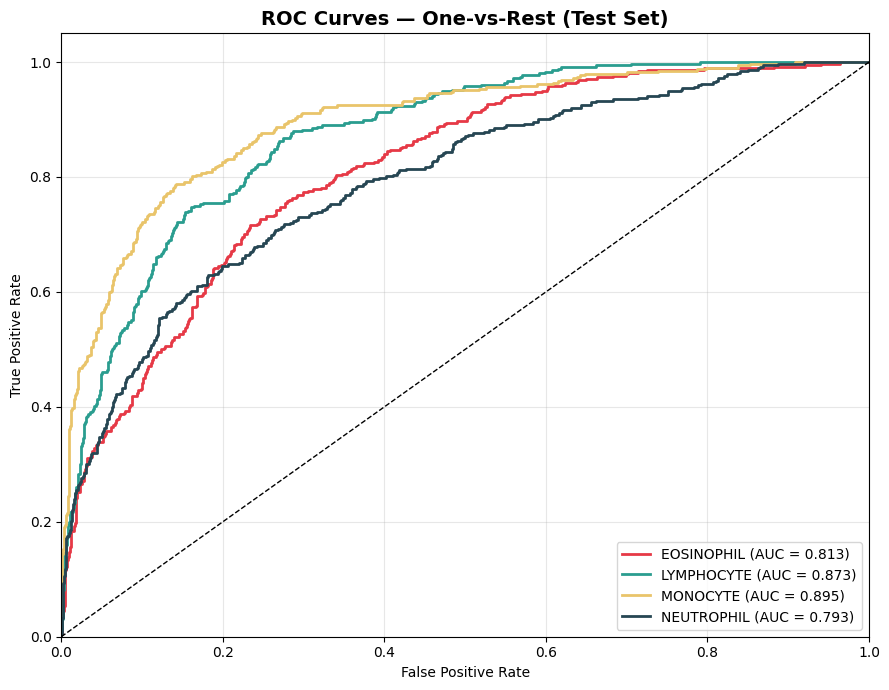

[INFO] ROC curve plot saved → roc_curves.png
[INFO] Model saved → model.pth

FINAL SUMMARY
  Best Val Accuracy : 0.6015
  Test Accuracy     : 0.6107
  Macro ROC-AUC     : 0.8434
  Model saved       : model.pth
  Confusion matrix  : confusion_matrix.png
  Training plot     : train_val_plot.png
  ROC curve plot    : roc_curves.png


In [7]:
# ============================================================
# InceptionV3 Transfer Learning — BCCD Dataset (4 Classes)
# Platform: Google Colab | Framework: PyTorch
# Run All → Results. No modifications needed.
# ============================================================

# --- Mount Google Drive (Optional) ---
# from google.colab import drive
# drive.mount('/content/drive')

# --- Install Dependencies ---
# --- Imports ---
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models import Inception_V3_Weights

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from tqdm import tqdm


# --- Config ---
DATA_DIR       = "/content/data"   # Folder with 4 class subfolders
NUM_CLASSES    = 4
IMG_SIZE       = 299
BATCH_SIZE     = 32
NUM_EPOCHS     = 10
LEARNING_RATE  = 1e-4
TRAIN_RATIO    = 0.70
VAL_RATIO      = 0.15
# TEST_RATIO   = 0.15 (remainder)
PATIENCE       = 3                  # Early stopping patience
SAVE_MODEL     = "model.pth"
SAVE_CM        = "confusion_matrix.png"
SAVE_PLOT      = "train_val_plot.png"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")


# --- Data Transforms ---
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


# --- Dataset Loading & Split ---
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
class_names  = full_dataset.classes
print(f"[INFO] Classes found: {class_names}")
print(f"[INFO] Total samples: {len(full_dataset)}")

n_total = len(full_dataset)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

# Apply val/test transforms (override the transform on subsets)
# We wrap the subsets to apply different transforms
class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        # img is already a tensor from the parent transform;
        # we need the PIL image instead — re-load from the original dataset
        orig_idx = self.subset.indices[idx]
        path, label = self.subset.dataset.samples[orig_idx]
        from PIL import Image
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

train_data = SubsetWithTransform(train_set, train_transforms)
val_data   = SubsetWithTransform(val_set,   val_test_transforms)
test_data  = SubsetWithTransform(test_set,  val_test_transforms)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"[INFO] Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")


# --- Model ---
weights = Inception_V3_Weights.IMAGENET1K_V1
model   = models.inception_v3(weights=weights)

# Freeze all layers except the final classifier
for param in model.parameters():
    param.requires_grad = False

# Replace final FC layers
model.fc       = nn.Linear(model.fc.in_features, NUM_CLASSES)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, NUM_CLASSES)

# Unfreeze the modified layers
for param in model.fc.parameters():
    param.requires_grad = True
for param in model.AuxLogits.fc.parameters():
    param.requires_grad = True

model = model.to(device)
print("[INFO] InceptionV3 loaded. Final FC layers replaced for 4 classes.")


# --- Loss, Optimizer, Scheduler ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    list(model.fc.parameters()) + list(model.AuxLogits.fc.parameters()),
    lr=LEARNING_RATE
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)


# --- Training & Validation Loop ---
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   []
}

best_val_acc   = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience_ctr   = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n{'='*55}")
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"{'='*55}")

    # ---------- TRAIN ----------
    model.train()
    train_loss, train_correct = 0.0, 0

    for imgs, labels in tqdm(train_loader, desc="  Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(imgs)
        # InceptionV3 returns (main_output, aux_output) during training
        if isinstance(outputs, tuple):
            main_out, aux_out = outputs
            loss = criterion(main_out, labels) + 0.4 * criterion(aux_out, labels)
            preds = torch.argmax(main_out, dim=1)
        else:
            loss  = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * imgs.size(0)
        train_correct += (preds == labels).sum().item()

    train_loss /= len(train_data)
    train_acc   = train_correct / len(train_data)

    # ---------- VALIDATE ----------
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc="  Val  ", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            loss  = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)
            val_loss    += loss.item() * imgs.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(val_data)
    val_acc   = val_correct / len(val_data)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    scheduler.step()

    # ---------- EARLY STOPPING ----------
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_ctr   = 0
        print(f"  [✓] Best model saved (val_acc={best_val_acc:.4f})")
    else:
        patience_ctr += 1
        print(f"  [!] No improvement. Patience: {patience_ctr}/{PATIENCE}")
        if patience_ctr >= PATIENCE:
            print("\n[INFO] Early stopping triggered.")
            break

# Restore best weights
model.load_state_dict(best_model_wts)
print(f"\n[INFO] Training complete. Best Val Acc: {best_val_acc:.4f}")


# --- Save Training Plot ---
epochs_ran = len(history["train_loss"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs_ran+1), history["train_loss"], label="Train Loss", marker="o")
ax1.plot(range(1, epochs_ran+1), history["val_loss"],   label="Val Loss",   marker="o")
ax1.set_title("Loss per Epoch"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(True)

ax2.plot(range(1, epochs_ran+1), history["train_acc"], label="Train Acc", marker="o")
ax2.plot(range(1, epochs_ran+1), history["val_acc"],   label="Val Acc",   marker="o")
ax2.set_title("Accuracy per Epoch"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(SAVE_PLOT, dpi=150, bbox_inches="tight")
plt.show()
print(f"[INFO] Training plot saved → {SAVE_PLOT}")


# --- Evaluation on Test Set ---
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="  Test "):
        imgs   = imgs.to(device)
        outputs = model(imgs)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        probs  = torch.softmax(outputs, dim=1)
        preds  = torch.argmax(probs,    dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)


# --- Metrics ---
print("\n" + "="*55)
print("TEST SET METRICS")
print("="*55)

# Accuracy
test_acc = (all_preds == all_labels).mean()
print(f"\nAccuracy: {test_acc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ROC-AUC (one-vs-rest, multiclass)
labels_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
roc_auc_per_class = {}
for i, cls in enumerate(class_names):
    roc_auc_per_class[cls] = roc_auc_score(labels_bin[:, i], all_probs[:, i])

macro_auc = roc_auc_score(labels_bin, all_probs, multi_class="ovr", average="macro")
print("ROC-AUC per class:")
for cls, score in roc_auc_per_class.items():
    print(f"  {cls:20s}: {score:.4f}")
print(f"Macro ROC-AUC: {macro_auc:.4f}")


# --- Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names, yticklabels=class_names,
    cmap="Blues", linewidths=0.5
)
plt.title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(SAVE_CM, dpi=150, bbox_inches="tight")
plt.show()
print(f"[INFO] Confusion matrix saved → {SAVE_CM}")


# --- ROC Curve Plot (all classes) ---
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#e63946", "#2a9d8f", "#e9c46a", "#264653"]
for i, (cls, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{cls} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — One-vs-Rest (Test Set)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("[INFO] ROC curve plot saved → roc_curves.png")


# --- Save Model ---
torch.save({
    "epoch":        epochs_ran,
    "model_state":  best_model_wts,
    "optimizer":    optimizer.state_dict(),
    "best_val_acc": best_val_acc,
    "class_names":  class_names,
}, SAVE_MODEL)
print(f"[INFO] Model saved → {SAVE_MODEL}")


# --- Final Summary ---
print("\n" + "="*55)
print("FINAL SUMMARY")
print("="*55)
print(f"  Best Val Accuracy : {best_val_acc:.4f}")
print(f"  Test Accuracy     : {test_acc:.4f}")
print(f"  Macro ROC-AUC     : {macro_auc:.4f}")
print(f"  Model saved       : {SAVE_MODEL}")
print(f"  Confusion matrix  : {SAVE_CM}")
print(f"  Training plot     : {SAVE_PLOT}")
print(f"  ROC curve plot    : roc_curves.png")
print("="*55)